In [43]:
import numpy as np
from scipy import stats
from math import factorial
import matplotlib.pyplot as plt

In [44]:
# Ex 1:
def g1(A,i):
    """Unnormalized target weight g(i) = A^i / i!, for i in {0,...,m}, else 0."""
    if i < 0 or i > m:
        return 0.0
    return A ** i / factorial(i)

def mh_truncated_poisson_1(x0,n_samples,A, burn_in=1000):

    np.random.seed(42)

    samples = np.empty(n_samples, dtype=int)

    for i in range(-burn_in, n_samples):
        y = x0 + np.random.choice((-1, 1))
        if np.random.uniform() < min(1.0, g1(A,y) / g1(A,x0)):
            x0 = y
        if i >= 0:
            samples[i] = x0

    return samples

def plot_mh_vs_true(states, observed, n_samples, true_pmf, A, m, dof=None, p_value=None, width=0.4, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 4))
    else:
        fig = ax.figure

    ax.bar(states - width / 2, observed / n_samples, width=width, label="MH samples (relative freq.)")
    ax.bar(states + width / 2, true_pmf, width=width, label="True P(i) = c A^i / i!")
    ax.set_xlabel("i (number of busy lines)")
    ax.set_ylabel("Probability")
    ax.set_title(f"Truncated Poisson, A={A}, m={m}: MH samples vs. true distribution")
    ax.set_xticks(states)
    ax.legend()

    fig.tight_layout()
    return fig, ax

A = 8.0, m = 10, n_samples = 100000

  i   observed   expected  true P(i)
  0         45      41.12     0.0004
  1        335     328.93     0.0033
  2       1329    1315.72     0.0132
  3       3483    3508.60     0.0351
  4       6965    7017.19     0.0702
  5      11099   11227.51     0.1123
  6      14715   14970.01     0.1497
  7      17024   17108.59     0.1711
  8      17306   17108.59     0.1711
  9      15423   15207.63     0.1521
 10      12276   12166.11     0.1217

Chi-square statistic: 13.742
Degrees of freedom:   10
p-value:              0.1851


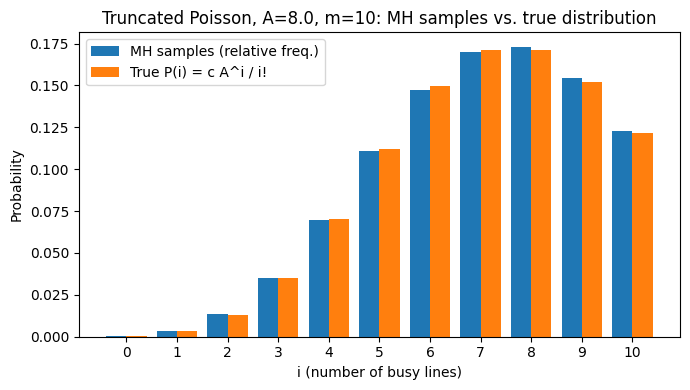

In [66]:
# Parameters from Exercise 4
A = 8.0
m = 10

states = np.arange(m + 1)
g_vals = np.array([g1(A,i) for i in states])
true_pmf = g_vals / g_vals.sum()

n_samples = 100000
rng = np.random.seed(42)

samples = mh_truncated_poisson_1(m//2,n_samples,A, burn_in=10000)

observed = np.array([np.sum(samples == i) for i in states])
expected = true_pmf * n_samples

chi2_stat, p_value = stats.chisquare(observed, f_exp=expected)
dof = m

print(f"A = {A}, m = {m}, n_samples = {n_samples}\n")
print(f"{'i':>3}  {'observed':>9}  {'expected':>9}  {'true P(i)':>9}")
for i in states:
    print(f"{i:>3}  {observed[i]:>9}  {expected[i]:>9.2f}  {true_pmf[i]:>9.4f}")

print(f"\nChi-square statistic: {chi2_stat:.3f}")
print(f"Degrees of freedom:   {dof}")
print(f"p-value:              {p_value:.4f}")

fig, ax = plot_mh_vs_true(states, observed, n_samples, true_pmf, A, m, dof=dof, p_value=p_value)
plt.show()

In [60]:
# Ex 2(a)
def g2(A1, A2, i, j):
    """Unnormalized target weight g(i,j) = A1^i/i! * A2^j/j!, for i,j>=0 and i+j<=m, else 0."""
    if i < 0 or j < 0 or i + j > m:
        return 0.0
    return A1 ** i / factorial(i) * A2 ** j / factorial(j)

def mh_truncated_poisson_2(x0, n_samples, A1, A2, burn_in=1000):
    """2D random-walk Metropolis sampler for P(i,j) ~ A1^i/i! * A2^j/j!, 0 <= i+j <= m.

    Proposes a move to one of the 4 neighbouring states (i+-1,j) or (i,j+-1), each
    with probability 1/4 (symmetric proposal), and accepts with probability
    min(1, g2(y)/g2(x)). Proposals leaving the simplex {i,j>=0, i+j<=m} have g2=0
    and are automatically rejected.
    """
    np.random.seed(42)

    moves = np.array([(1, 0), (-1, 0), (0, 1), (0, -1)])
    x = np.array(x0, dtype=int)
    samples = np.empty((n_samples, 2), dtype=int)

    for i in range(-burn_in, n_samples):
        y = x + moves[np.random.choice(4)]
        if np.random.uniform() < min(1.0, g2(A1, A2, y[0], y[1]) / g2(A1, A2, x[0], x[1])):
            x = y
        if i >= 0:
            samples[i] = x

    return samples

def plot_mh_vs_true_2d(observed, true_pmf, n_samples, A1, A2, m, dof=None, p_value=None, ax=None):
    grid = m + 1
    ii, jj = np.meshgrid(np.arange(grid), np.arange(grid), indexing="ij")
    mask = (ii + jj) > m

    observed_freq = np.ma.array(observed / n_samples, mask=mask)
    true_pmf_masked = np.ma.array(true_pmf, mask=mask)
    vmax = max(observed_freq.max(), true_pmf_masked.max())

    if ax is None:
        fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    else:
        fig = ax[0].figure

    im0 = ax[0].imshow(observed_freq.T, origin="lower", vmin=0, vmax=vmax, cmap="viridis")
    ax[0].set_title("MH samples (relative freq.)")

    im1 = ax[1].imshow(true_pmf_masked.T, origin="lower", vmin=0, vmax=vmax, cmap="viridis")
    ax[1].set_title("True P(i,j) = c A1^i/i! A2^j/j!")

    for a in ax:
        a.set_xlabel("i")
        a.set_ylabel("j")
        a.set_xticks(range(grid))
        a.set_yticks(range(grid))

    fig.suptitle(f"Joint truncated Poisson, A1={A1}, A2={A2}, m={m}")
    fig.colorbar(im1, ax=ax.tolist(), shrink=0.8, label="Probability")

    return fig, ax

A1 = 4, A2 = 4, m = 10, n_samples = 100000

Chi-square statistic: 316.252
Degrees of freedom:   65
p-value:              0.0000


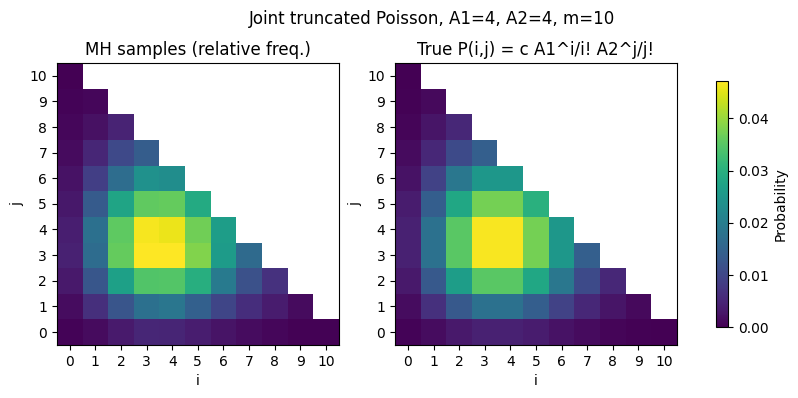

In [74]:
A1 = 4
A2 = 4
m = 10

ii, jj = np.meshgrid(np.arange(m + 1), np.arange(m + 1), indexing="ij")
valid = (ii + jj) <= m

g2_vals = np.zeros((m + 1, m + 1))
g2_vals[valid] = [g2(A1, A2, i, j) for i, j in zip(ii[valid], jj[valid])]
true_pmf = g2_vals / g2_vals.sum()

n_samples = 100000

samples = mh_truncated_poisson_2((m // 2, 0), n_samples, A1, A2, burn_in=1000)

observed = np.zeros((m + 1, m + 1))
for i, j in samples:
    observed[i, j] += 1

expected = true_pmf[valid] * n_samples
chi2_stat, p_value = stats.chisquare(observed[valid], f_exp=expected)
dof = valid.sum() - 1

print(f"A1 = {A1}, A2 = {A2}, m = {m}, n_samples = {n_samples}\n")
print(f"Chi-square statistic: {chi2_stat:.3f}")
print(f"Degrees of freedom:   {dof}")
print(f"p-value:              {p_value:.4f}")

fig, ax = plot_mh_vs_true_2d(observed, true_pmf, n_samples, A1, A2, m, dof=dof, p_value=p_value)
plt.show()

In [68]:
# Ex 2(b)
def mh_truncated_poisson_2_coordwise(x0, n_samples, A1, A2, burn_in=1000):
    """Coordinatewise random-walk Metropolis sampler for P(i,j) ~ A1^i/i! * A2^j/j!, 0 <= i+j <= m.

    Each iteration updates i and j in turn: for each coordinate, propose a +-1 step
    (symmetric), holding the other coordinate fixed, and accept with probability
    min(1, g2(y)/g2(x)). Proposals leaving the simplex {i,j>=0, i+j<=m} have g2=0
    and are automatically rejected.
    """
    np.random.seed(42)

    x = np.array(x0, dtype=int)
    samples = np.empty((n_samples, 2), dtype=int)

    for i in range(-burn_in, n_samples):
        for coord in range(2):
            y = x.copy()
            y[coord] += np.random.choice((-1, 1))
            if np.random.uniform() < min(1.0, g2(A1, A2, y[0], y[1]) / g2(A1, A2, x[0], x[1])):
                x = y
        if i >= 0:
            samples[i] = x

    return samples

A1 = 4, A2 = 4, m = 10, n_samples = 100000

Chi-square statistic: 135.543
Degrees of freedom:   65
p-value:              0.0000


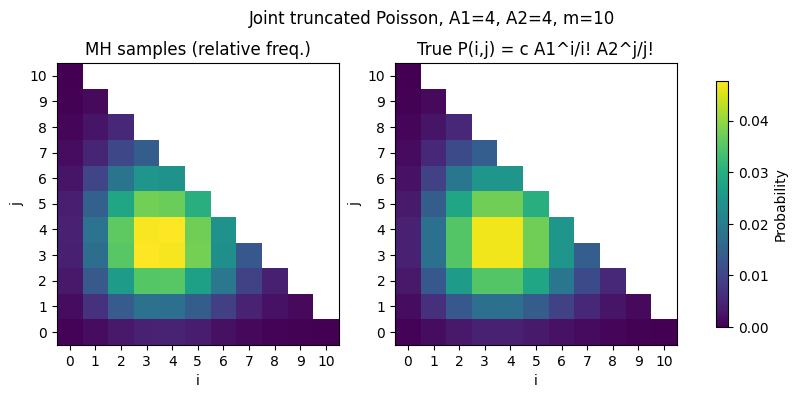

In [69]:
samples_cw = mh_truncated_poisson_2_coordwise((m // 2, 0), n_samples, A1, A2, burn_in=1000)

observed_cw = np.zeros((m + 1, m + 1))
for i, j in samples_cw:
    observed_cw[i, j] += 1

expected_cw = true_pmf[valid] * n_samples
chi2_stat_cw, p_value_cw = stats.chisquare(observed_cw[valid], f_exp=expected_cw)
dof_cw = valid.sum() - 1

print(f"A1 = {A1}, A2 = {A2}, m = {m}, n_samples = {n_samples}\n")
print(f"Chi-square statistic: {chi2_stat_cw:.3f}")
print(f"Degrees of freedom:   {dof_cw}")
print(f"p-value:              {p_value_cw:.4f}")

fig, ax = plot_mh_vs_true_2d(observed_cw, true_pmf, n_samples, A1, A2, m, dof=dof_cw, p_value=p_value_cw)
plt.show()

In [70]:
# Ex 2(c)
def sample_truncated_poisson(A, M):
    """Sample k ~ P(k) = A^k/k! / sum_{l=0}^{M} A^l/l!, for k in {0,...,M}."""
    k = np.arange(M + 1)
    weights = A ** k / np.array([factorial(kk) for kk in k])
    probs = weights / weights.sum()
    return np.random.choice(k, p=probs)

def gibbs_truncated_poisson_2(x0, n_samples, A1, A2, burn_in=1000):
    """Gibbs sampler for P(i,j) ~ A1^i/i! * A2^j/j!, 0 <= i+j <= m.

    Alternately draws i from its conditional distribution given j, then j from its
    conditional distribution given the updated i -- both are exact draws from
    truncated Poisson distributions, so every proposal is accepted.
    """
    np.random.seed(42)

    x = np.array(x0, dtype=int)
    samples = np.empty((n_samples, 2), dtype=int)

    for it in range(-burn_in, n_samples):
        x[0] = sample_truncated_poisson(A1, m - x[1])
        x[1] = sample_truncated_poisson(A2, m - x[0])
        if it >= 0:
            samples[it] = x

    return samples


A1 = 4, A2 = 4, m = 10, n_samples = 100000

Chi-square statistic: 35.914
Degrees of freedom:   65
p-value:              0.9987


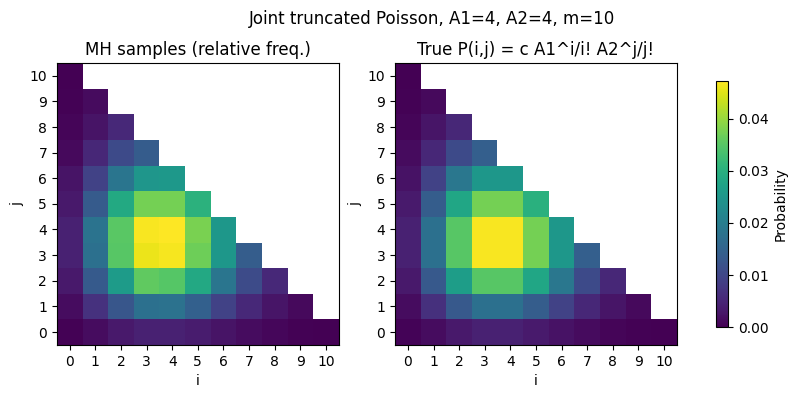

In [71]:
samples_gibbs = gibbs_truncated_poisson_2((m // 2, 0), n_samples, A1, A2, burn_in=1000)

observed_gibbs = np.zeros((m + 1, m + 1))
for i, j in samples_gibbs:
    observed_gibbs[i, j] += 1

expected_gibbs = true_pmf[valid] * n_samples
chi2_stat_gibbs, p_value_gibbs = stats.chisquare(observed_gibbs[valid], f_exp=expected_gibbs)
dof_gibbs = valid.sum() - 1

print(f"A1 = {A1}, A2 = {A2}, m = {m}, n_samples = {n_samples}\n")
print(f"Chi-square statistic: {chi2_stat_gibbs:.3f}")
print(f"Degrees of freedom:   {dof_gibbs}")
print(f"p-value:              {p_value_gibbs:.4f}")

fig, ax = plot_mh_vs_true_2d(observed_gibbs, true_pmf, n_samples, A1, A2, m, dof=dof_gibbs, p_value=p_value_gibbs)
plt.show()
